
## End-to-End CNN Model for Image Classification (Amazon Fruits Dataset)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Setup: Install & Import Required Libraries

In [8]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"📦 Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Semester6_AI ML/Week 5/Copy of FruitinAmazon.zip', '/content/output')

📦 Found 120 files | Size: 1.2 MB


Extracting: 100%|██████████| 120/120 [00:00<00:00, 441.95file/s]

Done! Files saved to: /content/output


In [9]:
# Install required libraries (uncomment if needed)
# !pip install tensorflow scikit-learn matplotlib numpy Pillow

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


---
## Dataset Setup




In [10]:

# SET YOUR DATASET PATH HERE

DATASET_PATH = "/content/output/FruitinAmazon"
train_dir    = os.path.join(DATASET_PATH, "train")
test_dir     = os.path.join(DATASET_PATH, "test")

# Hyperparameters
IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 16
EPOCHS          = 250
VALIDATION_SPLIT = 0.2
SEED            = 123

# Verify paths exist
print("Train directory exists:", os.path.isdir(train_dir))
print("Test  directory exists:", os.path.isdir(test_dir))

Train directory exists: True
Test  directory exists: True


---
## Task 1.1 – Data Understanding and Visualization
Load and visualize one random image per class in a grid.

Number of classes: 6
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


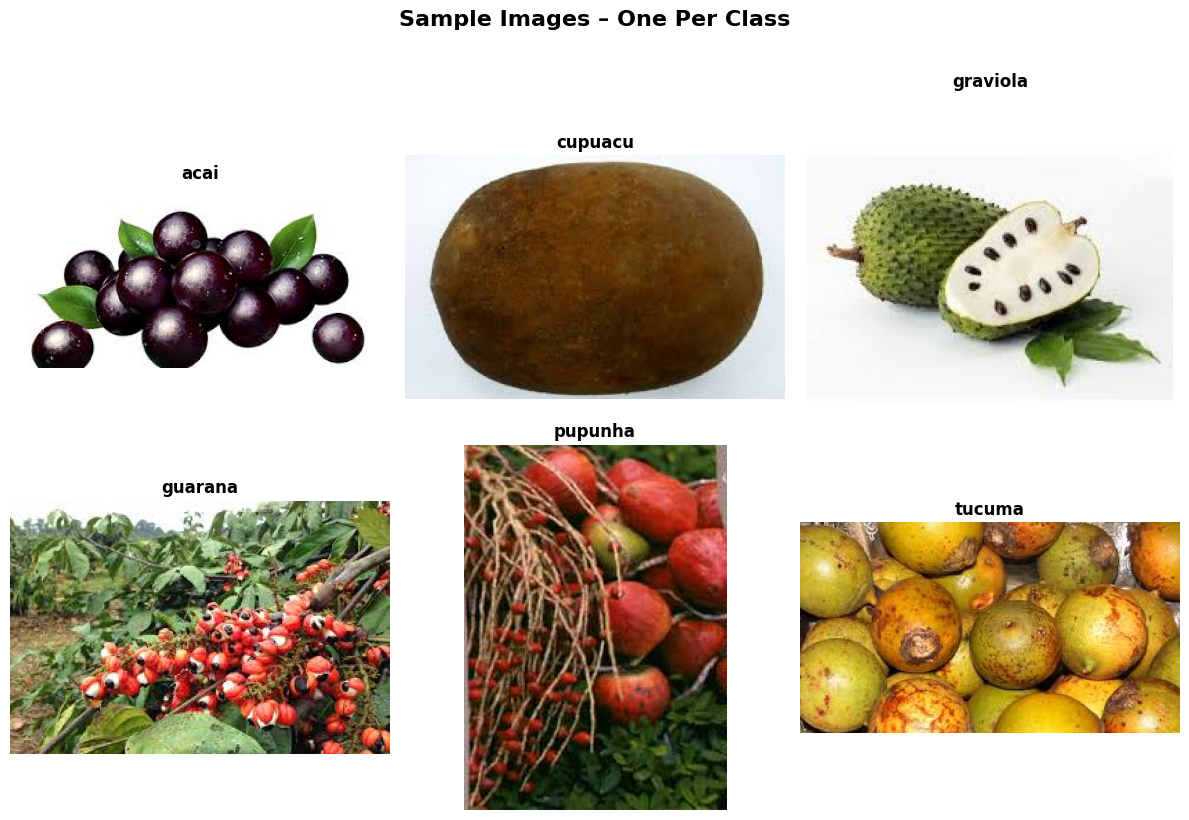


Visualization saved as task1_visualization.png


In [11]:

# Task 1.1: Visualize one image per class


# Get all class subdirectories from the train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

num_classes = len(class_dirs)
print(f"Number of classes: {num_classes}")
print(f"Classes found: {class_dirs}")

# Select one random image from each class
sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path  = os.path.join(train_dir, cls)
    all_imgs  = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    if all_imgs:
        chosen = random.choice(all_imgs)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# Display images in a grid with 2 rows
cols = (num_classes + 1) // 2      # number of columns
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide any unused axes
for j in range(len(sample_images), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images – One Per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task1_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nVisualization saved as task1_visualization.png")

(Task 1.1)


---
## Task 1.2 – Check for Corrupted Images

In [12]:

corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        image_path = os.path.join(cls_path, fname)
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            continue
        try:
            img = Image.open(image_path)
            img.verify()   # Verify it is an intact image
        except (IOError, SyntaxError) as e:
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2 – Load and Preprocess Image Data using Keras

In [13]:


# Normalization layer: scales pixel values from [0,255] → [0,1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

#  Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (IMG_HEIGHT, IMG_WIDTH),
    interpolation   = 'nearest',
    batch_size      = BATCH_SIZE,
    shuffle         = True,
    validation_split= VALIDATION_SPLIT,
    subset          = 'training',
    seed            = SEED
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#  Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (IMG_HEIGHT, IMG_WIDTH),
    interpolation   = 'nearest',
    batch_size      = BATCH_SIZE,
    shuffle         = False,
    validation_split= VALIDATION_SPLIT,
    subset          = 'validation',
    seed            = SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

#  Test Dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (IMG_HEIGHT, IMG_WIDTH),
    interpolation   = 'nearest',
    batch_size      = BATCH_SIZE,
    shuffle         = False,
    seed            = SEED
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Get class names
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else class_dirs
num_classes = len(class_names)

print(f"Class names : {class_names}")
print(f"Num classes : {num_classes}")
print(f"\nDatasets created:")
print(f"  train_ds  : {train_ds}")
print(f"  val_ds    : {val_ds}")
print(f"  test_ds   : {test_ds}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6

Datasets created:
  train_ds  : <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
  val_ds    : <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
  test_ds   : <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


---
## Task 3 – Build the CNN Model

Architecture as specified in the worksheet:
- Conv2D (32 filters, 3×3, same padding, ReLU) → MaxPool (2×2)
- Conv2D (32 filters, 3×3, same padding, ReLU) → MaxPool (2×2)
- Flatten → Dense(64, ReLU) → Dense(128, ReLU) → Dense(num_classes, Softmax)

In [14]:


def build_cnn(input_shape, num_classes):
    """
    Builds the CNN as specified in Worksheet 5.

    Architecture:
      Conv2D(32, 3x3, same, relu) → MaxPool(2x2)
      Conv2D(32, 3x3, same, relu) → MaxPool(2x2)
      Flatten
      Dense(64,  relu)
      Dense(128, relu)
      Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        #  Convolutional Block 1
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            padding     = 'same',
            strides     = (1, 1),
            activation  = 'relu',
            input_shape = input_shape,
            name        = 'conv2d_1'
        ),
        layers.MaxPooling2D(
            pool_size = (2, 2),
            strides   = (2, 2),
            name      = 'maxpool_1'
        ),

        #  Convolutional Block 2
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            padding     = 'same',
            strides     = (1, 1),
            activation  = 'relu',
            name        = 'conv2d_2'
        ),
        layers.MaxPooling2D(
            pool_size = (2, 2),
            strides   = (2, 2),
            name      = 'maxpool_2'
        ),

        #  Fully Connected Network
        layers.Flatten(name='flatten'),

        # Hidden Layer 1
        layers.Dense(64, activation='relu', name='dense_64'),

        # Hidden Layer 2
        layers.Dense(128, activation='relu', name='dense_128'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='CNN_Worksheet5')

    return model

# Build the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)   # RGB images
model = build_cnn(input_shape, num_classes)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Worksheet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4 – Compile and Train the Model

In [15]:

model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled successfully!")
print("  Optimizer : Adam")
print("  Loss      : sparse_categorical_crossentropy")
print("  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : sparse_categorical_crossentropy
  Metrics   : accuracy


In [16]:


# ModelCheckpoint – saves the best model during training
checkpoint_cb = ModelCheckpoint(
    filepath          = 'best_model.h5',
    monitor           = 'val_accuracy',
    save_best_only    = True,
    mode              = 'max',
    verbose           = 1
)

# EarlyStopping – stops training when validation loss stops improving
early_stop_cb = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,            # wait 20 epochs before stopping
    restore_best_weights = True,
    verbose              = 1
)

callbacks = [checkpoint_cb, early_stop_cb]
print("Callbacks ready: ModelCheckpoint + EarlyStopping")

Callbacks ready: ModelCheckpoint + EarlyStopping


In [ ]:
# -------------------------------------------------------
# Task 4c: Train the Model
# -------------------------------------------------------

history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

print("\nTraining complete!")

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.2434 - loss: 1.9835
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 728ms/step - accuracy: 0.2222 - loss: 2.0276 - val_accuracy: 0.0556 - val_loss: 2.1682
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.3875 - loss: 1.6535
Epoch 2: val_accuracy improved from 0.05556 to 0.38889, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 787ms/step - accuracy: 0.3333 - loss: 1.6552 - val_accuracy: 0.3889 - val_loss: 1.5840
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.4201 - loss: 1.4419
Epoch 3: val_accuracy improved from 0.38889 to 0.50000, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 680ms/step - accuracy: 0.4028 - loss: 1.3950 - val_accuracy: 0.5000 - val_loss: 1.3099
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6309 - loss: 1.1238
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.6389 - loss: 1.1061 - val_accuracy: 0.5000 - val_loss: 1.1086
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8028 - loss: 0.7992
Epoch 5: val_accuracy improved from 0.50000 to 0.83333, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.7639 - loss: 0.8402 - val_accuracy: 0.8333 - val_loss: 0.8923
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.8083 - loss: 0.6999
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - accuracy: 0.7917 - loss: 0.7063 - val_accuracy: 0.3889 - val_loss: 1.1552
Epoch 7/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.8906 - loss: 0.4684

---
## Visualization – Training & Validation Loss/Accuracy

In [ ]:

# Visualization: Training vs Validation Loss & Accuracy


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Loss Plot
axes[0].plot(history.history['loss'],     label='Train Loss',      color='royalblue',  linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',        color='tomato',     linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch',  fontsize=12)
axes[0].set_ylabel('Loss',   fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy Plot
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='seagreen',   linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange',  linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch',    fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved as training_curves.png")

---
## Task 5 – Evaluate the Model

In [ ]:

# Task 5: Evaluate the model on the test set


test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*40}")

---
## Task 6 – Save and Load the Model

In [ ]:

# Task 6a: Save the trained model


MODEL_SAVE_PATH = 'cnn_fruit_classifier.h5'
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

In [ ]:

# Task 6b: Load the saved model and re-evaluate


loaded_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f"Model loaded from: {MODEL_SAVE_PATH}")

# Re-evaluate on test set
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)")
print(f"{'='*40}")
print(" Loaded model performance matches original model – save/load successful!")

---
## Task 7 – Predictions and Classification Report

In [ ]:

# Task 7: Predictions and Classification Report


# Collect all predictions and true labels from test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)   # Convert probabilities → class labels

print(f"Total test samples : {len(y_true)}")
print(f"Sample true labels : {y_true[:10]}")
print(f"Sample pred labels : {y_pred[:10]}")

In [ ]:

# Classification Report

print("\n" + "="*55)
print("          CLASSIFICATION REPORT")
print("="*55)
report = classification_report(
    y_true,
    y_pred,
    target_names = class_names,
    digits       = 2
)
print(report)

In [ ]:
# -------------------------------------------------------
# Visualize Predictions on Sample Test Images
# -------------------------------------------------------

# Get first batch from test_ds for visualization
sample_images_batch, sample_labels_batch = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images_batch, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(8, len(sample_labels_batch))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    img   = sample_images_batch[i].numpy()
    true  = class_names[sample_labels_batch[i].numpy()]
    pred  = class_names[sample_pred_labels[i]]
    conf  = sample_preds[i][sample_pred_labels[i]] * 100
    color = 'green' if true == pred else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true}\nPred: {pred} ({conf:.1f}%)",
        fontsize=10, color=color, fontweight='bold'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Predictions on Test Images  (Green = Correct | Red = Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions visualization saved as predictions_visualization.png")

---
## Summary of Deliverables

| Deliverable | Status |
|---|---|
|  Task 1.1 – Data Visualization (grid of class samples) | Complete |
|  Task 1.2 – Corrupted Image Detection & Removal | Complete |
|  Task 2  – Data Loading & Preprocessing | Complete |
|  Task 3  – CNN Model Architecture | Complete |
|  Task 4  – Model Compilation & Training (Adam, sparse CE, EarlyStopping, Checkpoint) | Complete |
|  Task 5  – Model Evaluation on Test Set | Complete |
|  Task 6  – Save (`cnn_fruit_classifier.h5`) & Load + Re-evaluate | Complete |
|  Task 7  – Predictions with `np.argmax()` + Classification Report | Complete |
|  Visualization – Loss & Accuracy training curves | Complete |

### Key Files Generated
- `cnn_fruit_classifier.h5`  – Final saved model
- `best_model.h5`            – Best checkpoint during training
- `training_curves.png`      – Loss & accuracy plots
- `task1_visualization.png`  – Sample class images
- `predictions_visualization.png` – Prediction results on test samples